In [116]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:86% !important;}
div.cell.code_cell.rendered{width:100%;}
div.CodeMirror {font-family:Consolas; font-size:12pt;}
div.output {font-size:15pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:12pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:12pt;padding:5px;}
table.dataframe{font-size:15px;}
</style>
"""))

# 라이브러리 버젼 체크 : 충돌방지

In [117]:
import numpy as np
np.__version__

'2.0.2'

In [118]:
import sklearn
sklearn.__version__

'1.7.1'

In [119]:
import pandas as pd
pd.__version__

'2.3.0'

# 데이터 체크

In [120]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition_변환.csv')
df

,나이,회사와의마찰,출장,일당,부서,거리,학력,전공,사번,만족도,...,성인여부,야근,업무평가,주변평가,근무기준시간,스톡옵션레벨,경력,전년도교육출장횟수,워라밸,현회사근속년수
0,41,Yes,1~29회,1102,영업,1,2,사회과학계열,1,2,...,Y,Yes,보통,1,80,0,8,0,1,6
1,49,No,30회 이상,279,R&D,8,1,사회과학계열,2,3,...,Y,No,좋다,4,80,1,10,3,3,10
2,37,Yes,1~29회,1373,R&D,2,2,기타,4,4,...,Y,Yes,보통,2,80,0,7,3,3,0
3,33,No,30회 이상,1392,R&D,3,4,사회과학계열,5,4,...,Y,Yes,보통,3,80,0,8,3,3,8
4,27,No,1~29회,591,R&D,2,1,자연과학계열,7,1,...,Y,No,보통,4,80,1,6,3,3,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,30회 이상,884,R&D,23,2,자연과학계열,2061,3,...,Y,No,보통,3,80,1,17,3,3,5
1466,39,No,1~29회,613,R&D,6,1,자연과학계열,2062,4,...,Y,No,보통,1,80,1,9,5,3,7
1467,27,No,1~29회,155,R&D,4,3,사회과학계열,2064,2,...,Y,Yes,좋다,2,80,1,6,0,3,6
1468,49,No,30회 이상,1023,영업,2,3,자연과학계열,2065,4,...,Y,No,보통,4,80,0,17,3,2,9


In [121]:
df[df.isna().any(axis=1)] # 결측치 0건

,나이,회사와의마찰,출장,일당,부서,거리,학력,전공,사번,만족도,...,성인여부,야근,업무평가,주변평가,근무기준시간,스톡옵션레벨,경력,전년도교육출장횟수,워라밸,현회사근속년수


In [122]:
df.columns

Index(['나이', '회사와의마찰', '출장', '일당', '부서', '거리', '학력', '전공', '사번', '만족도', '성별',
       '시급', '참여프로젝트', '근속연차', '직급', '직업만족도', '결혼여부', '월급', '이직회수', '성인여부',
       '야근', '업무평가', '주변평가', '근무기준시간', '스톡옵션레벨', '경력', '전년도교육출장횟수', '워라밸',
       '현회사근속년수'],
      dtype='object')

In [123]:
x_col = ['나이','출장','부서','학력','전공','참여프로젝트','직급','경력','전년도교육출장횟수','현회사근속년수']
y_col = ['업무평가']

# 독립변수 데이터 분포 점검
- 데이터의 형태가 심각하게 비정규성을 띄고
- 샘플 모델의 accuracy가 너무 낮다면
- 스케일링 통해 분포를 맞출 필요
- 또한 feature importance가 낮은데 불균등 분포여도 feature 제거 고려

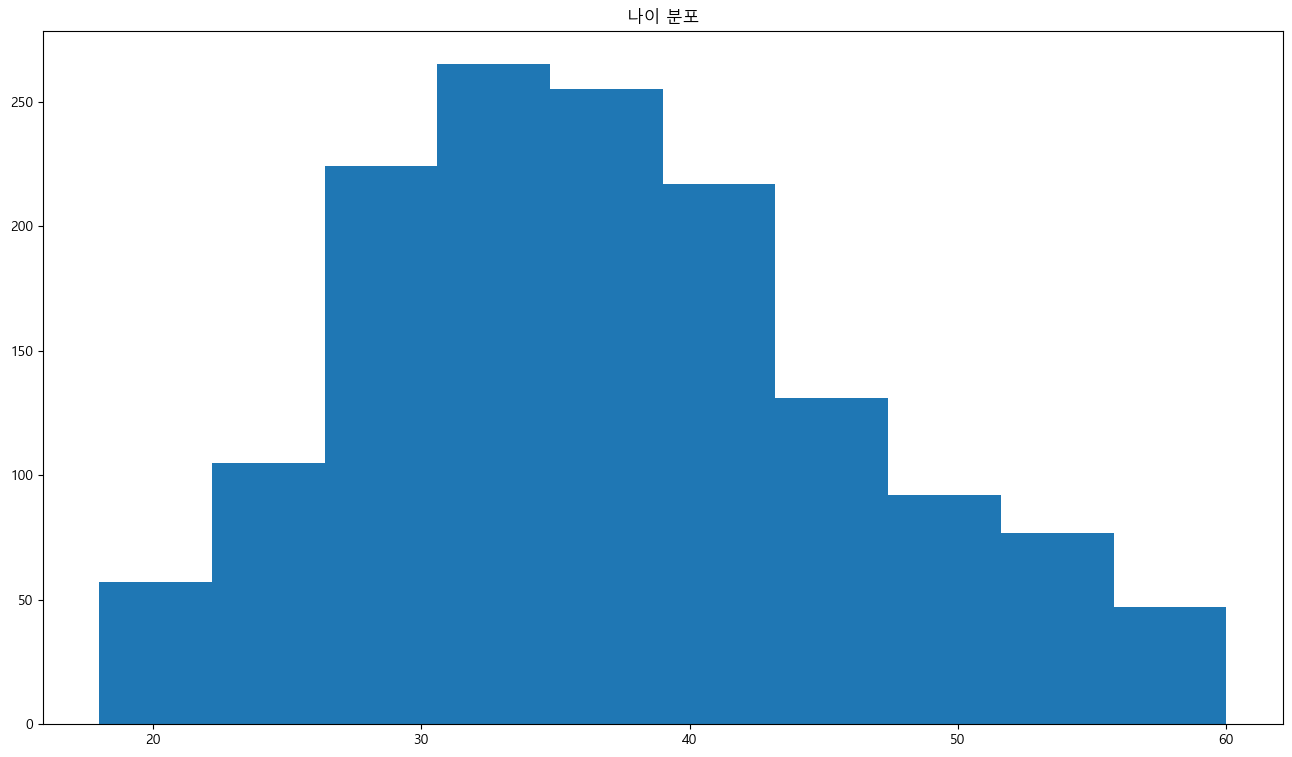

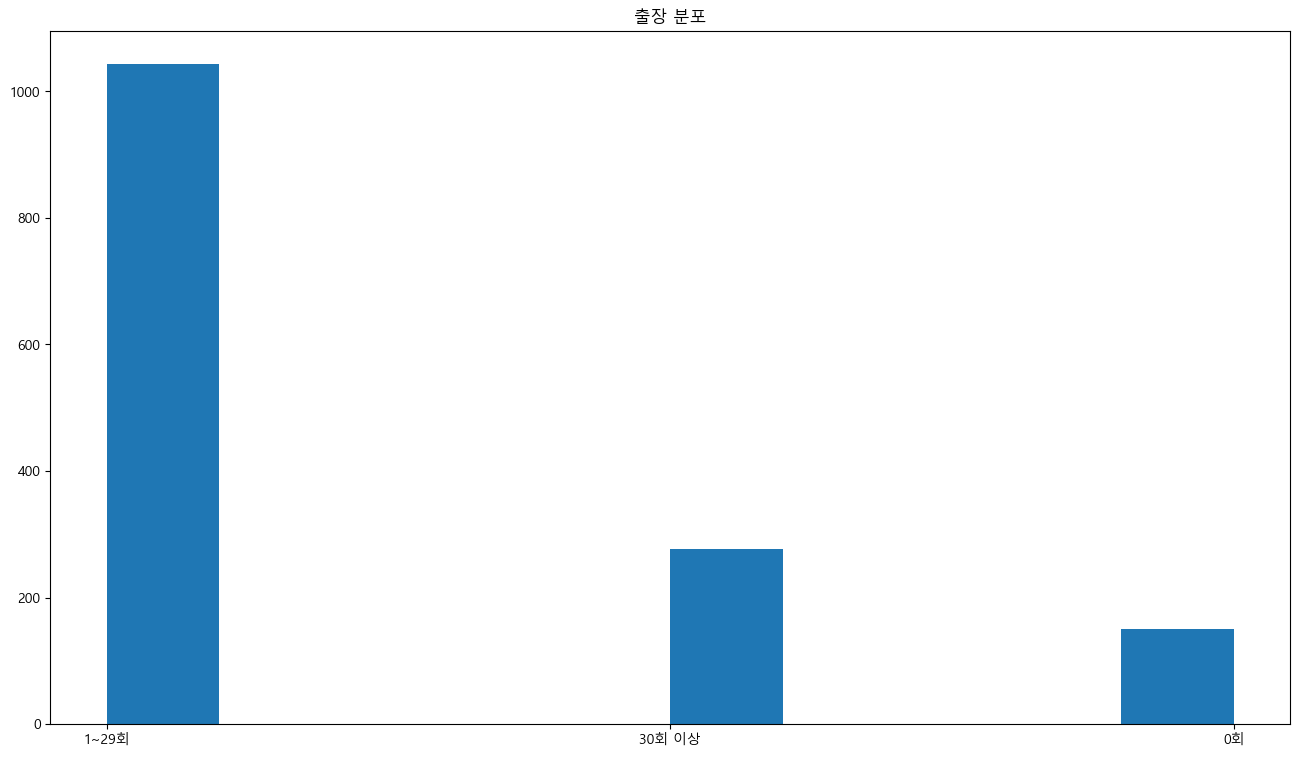

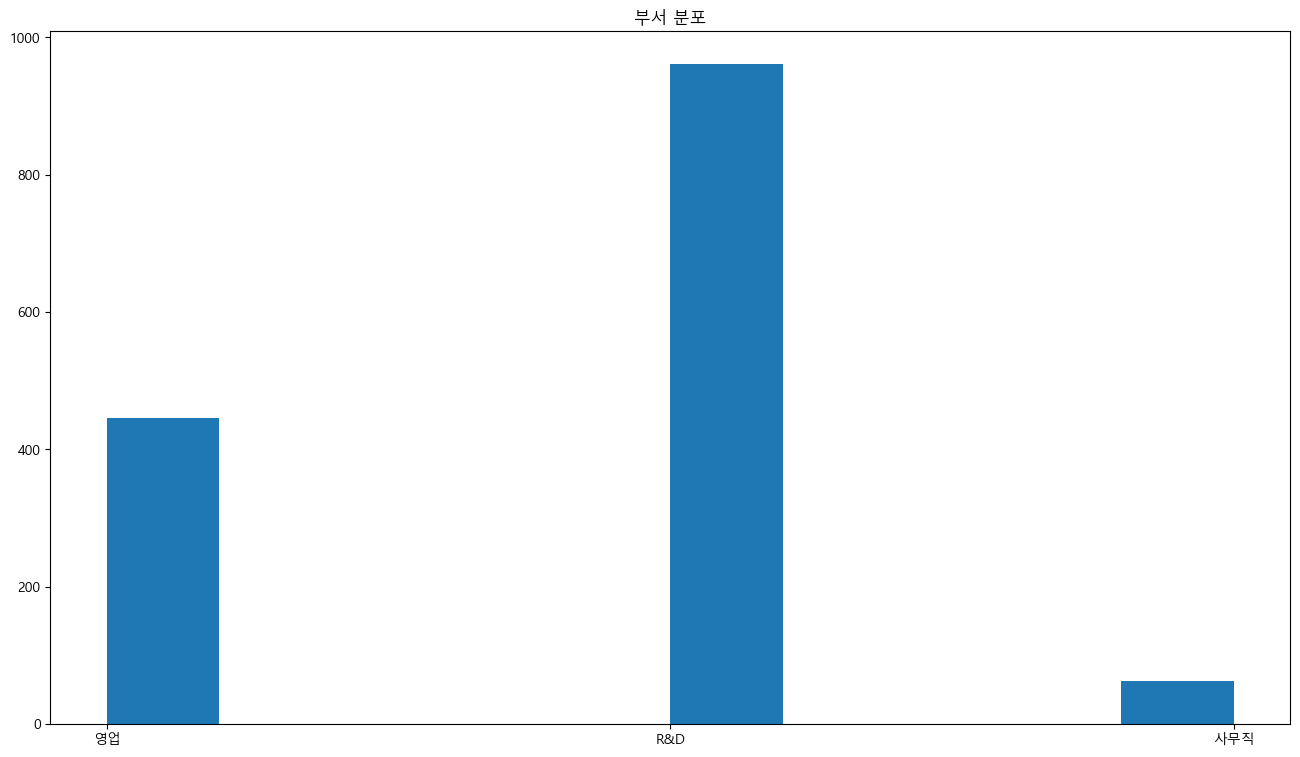

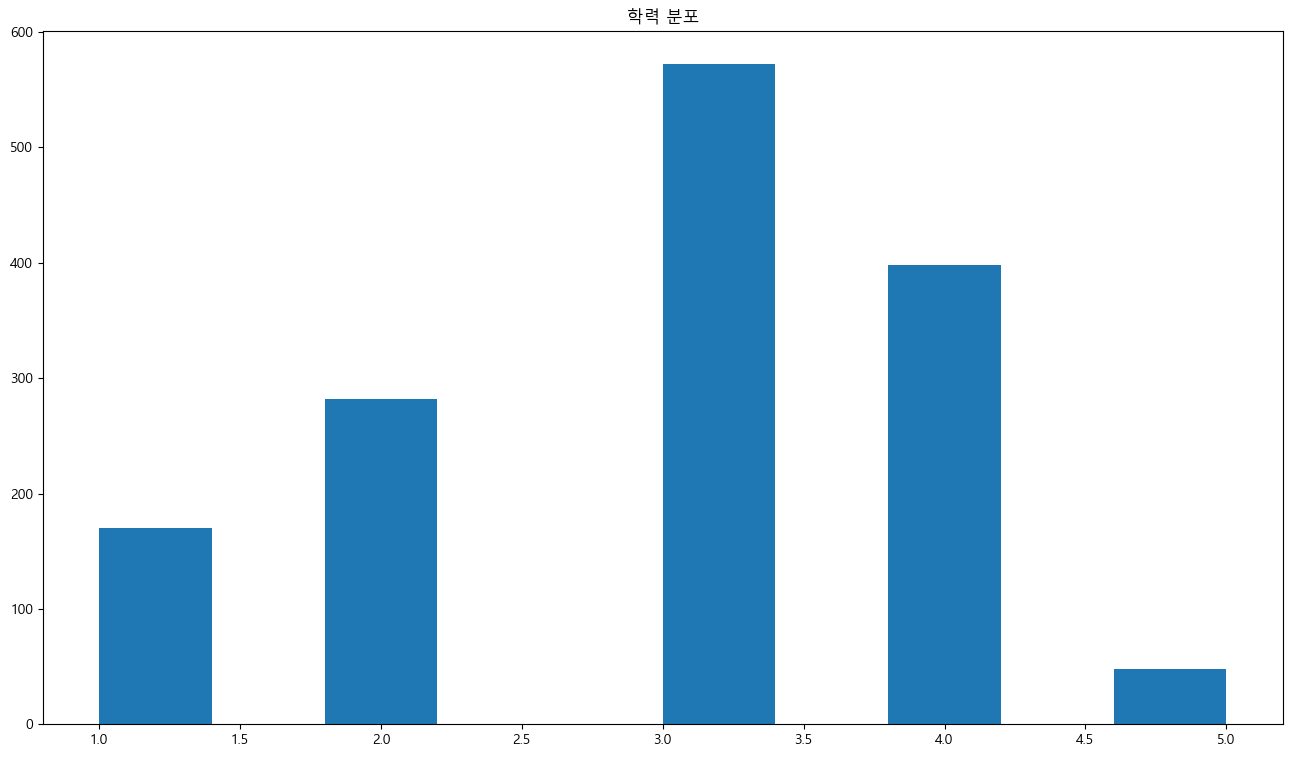

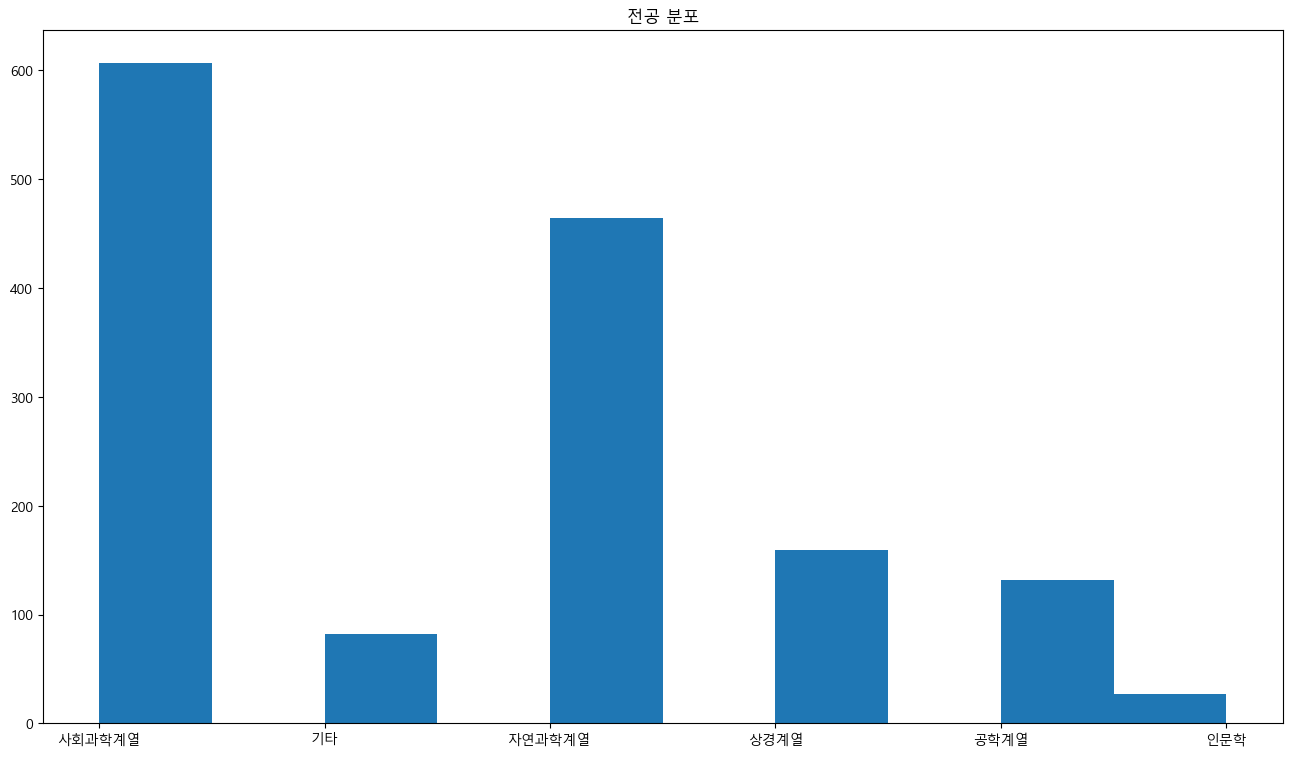

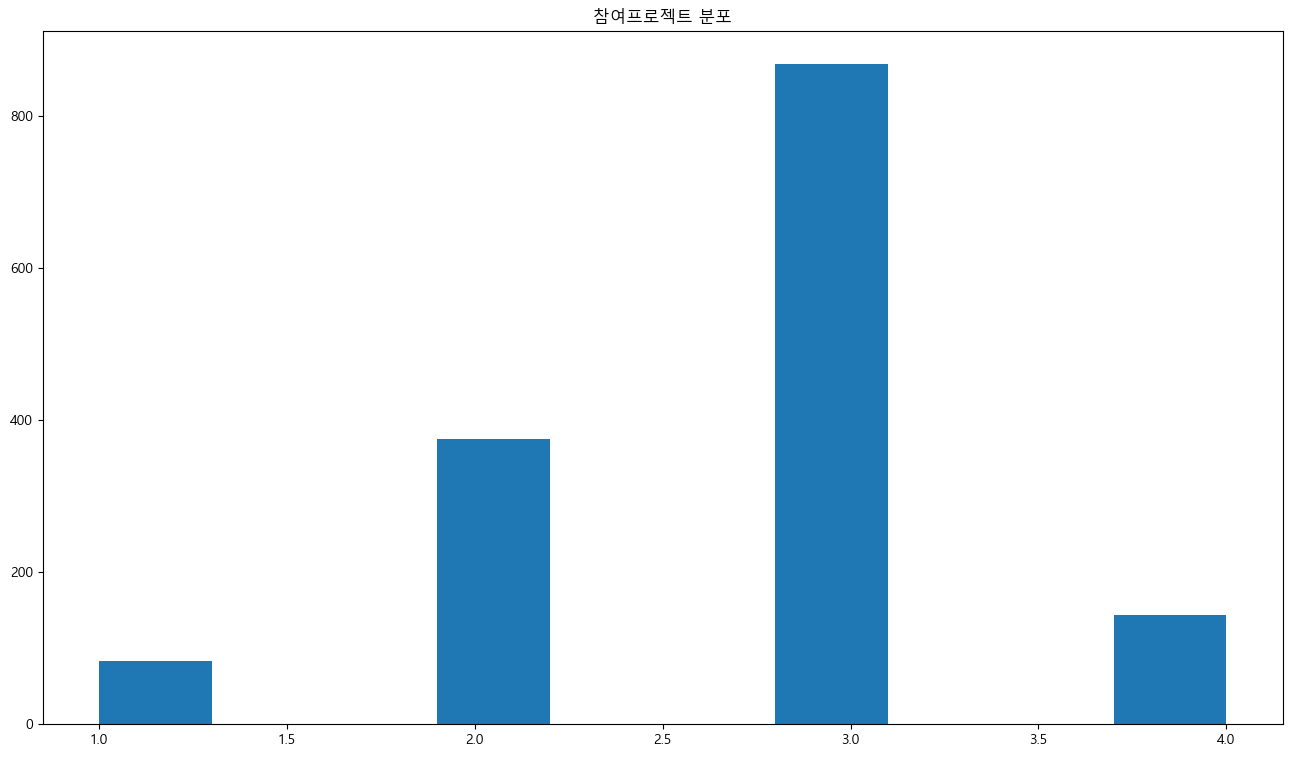

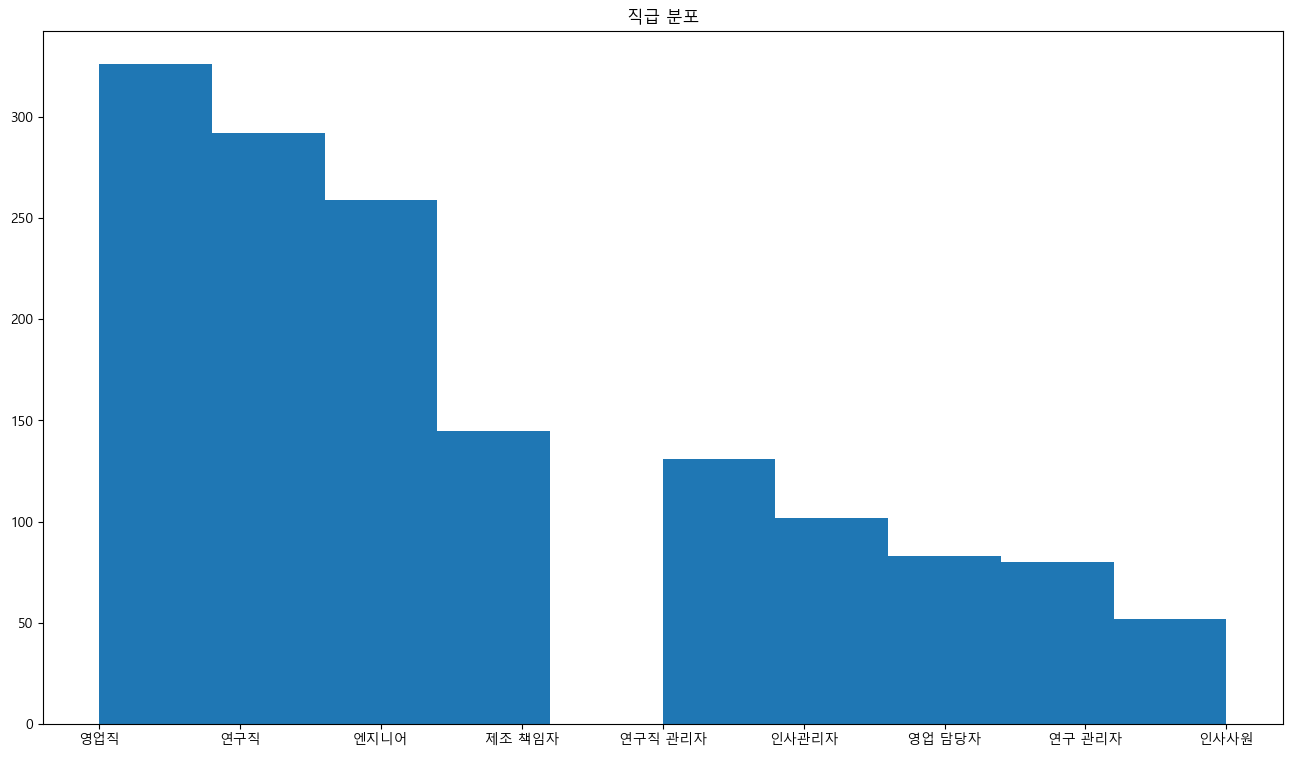

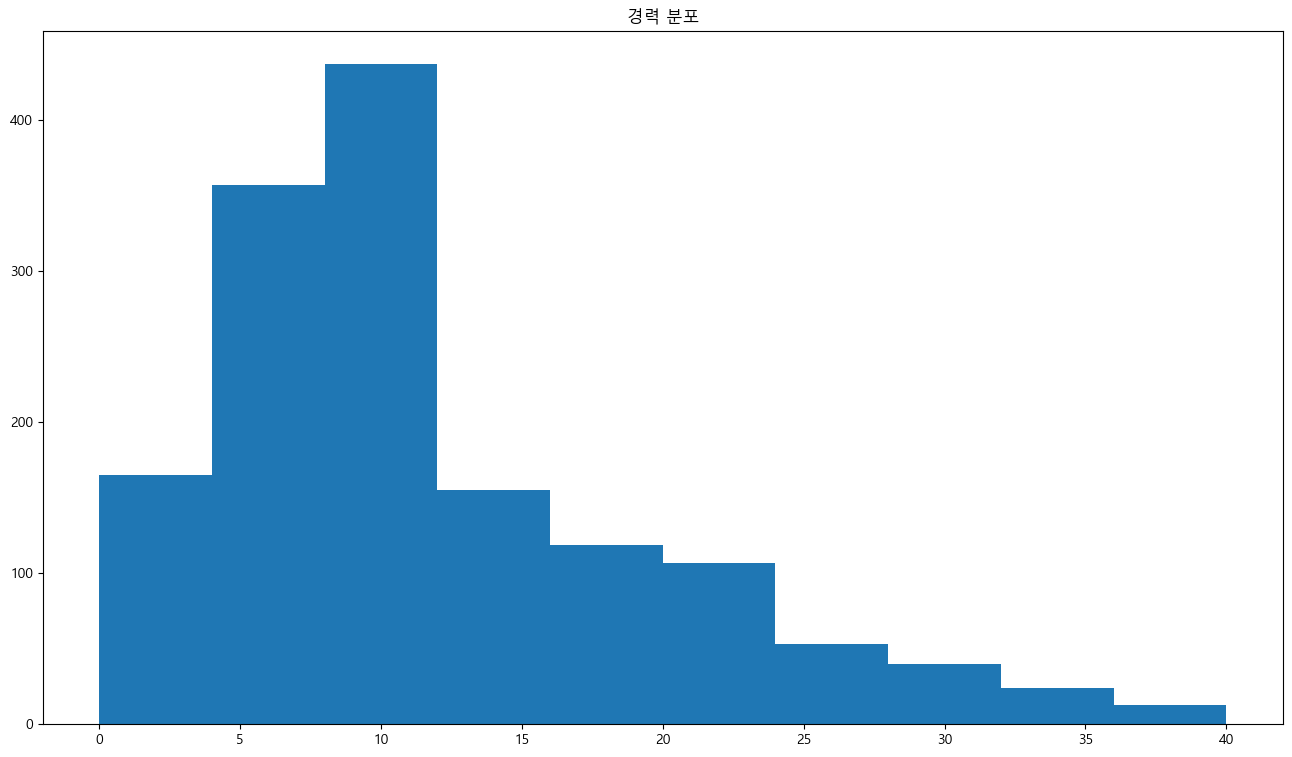

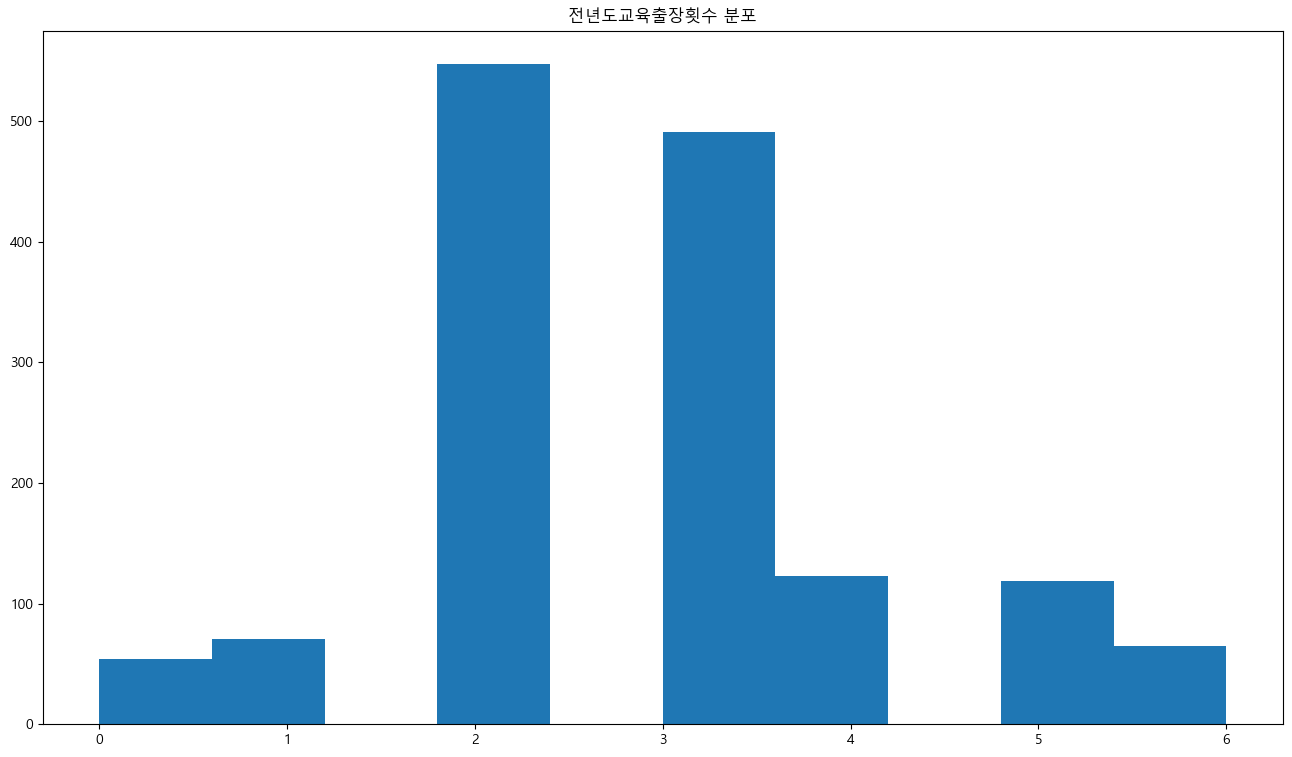

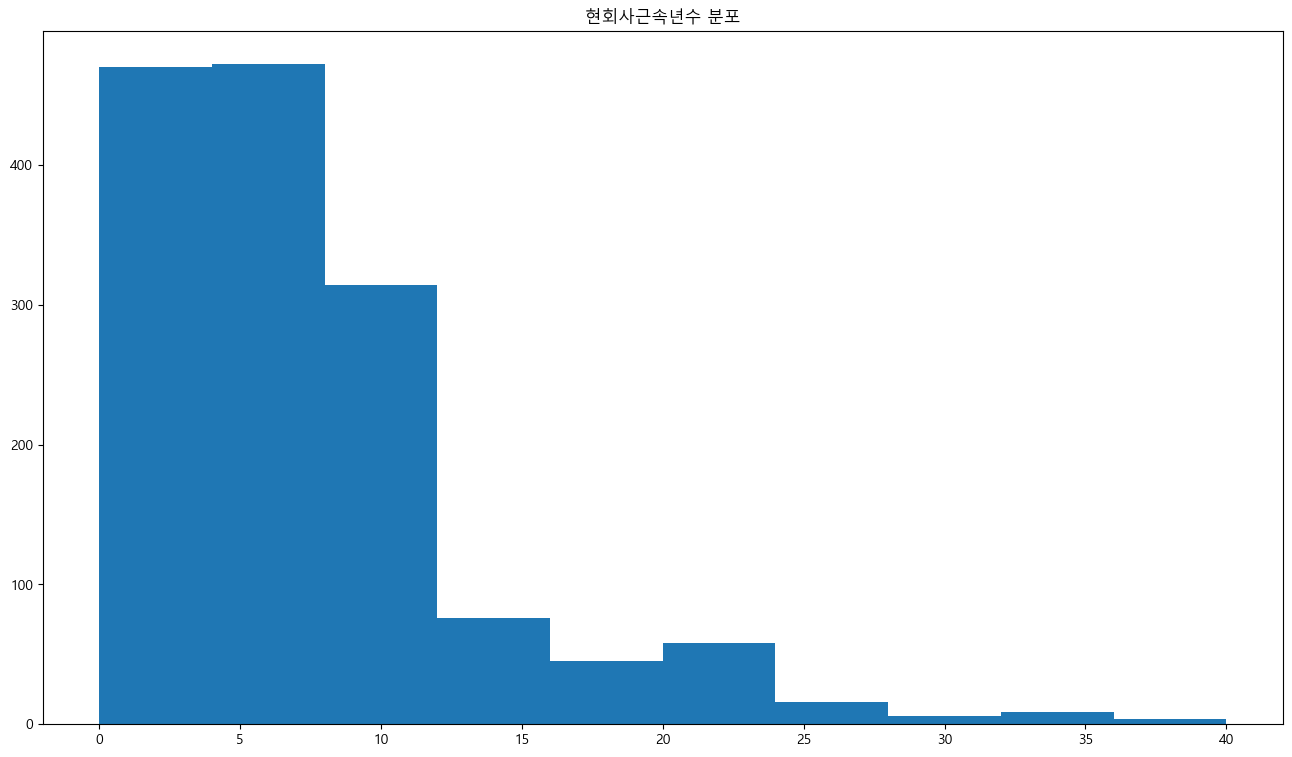

In [124]:
import matplotlib.pyplot as plt
plt.rc("font", family="Malgun Gothic")
for col in x_col :
    plt.figure(figsize=(16,9))
    plt.hist(df[col])
    plt.title(f"{col} 분포")
#     print(df[col].value_counts()) # 데이터 분포가 비정상적


# 타겟변수 분포 점검

In [125]:
df['업무평가'].value_counts()

업무평가
보통    1244
좋다     226
Name: count, dtype: int64

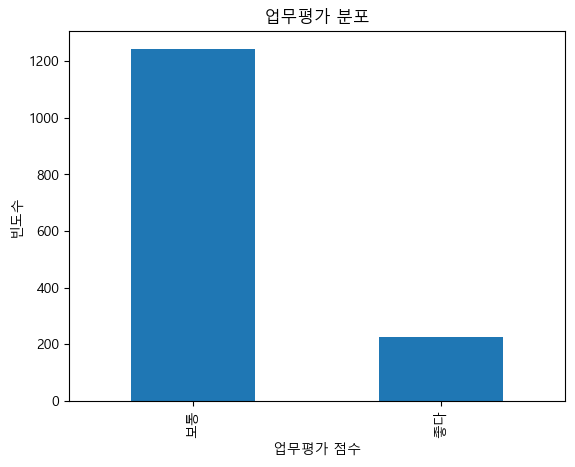

In [126]:
df['업무평가'].value_counts().sort_index().plot(kind='bar')
plt.title("업무평가 분포")
plt.xlabel("업무평가 점수")
plt.ylabel("빈도수")
plt.show()

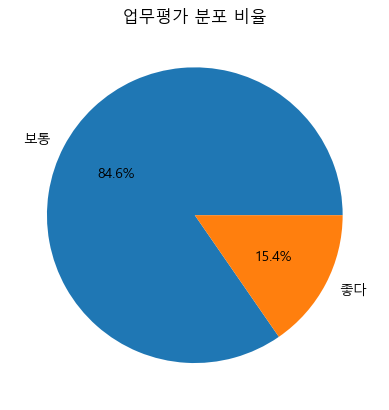

In [127]:
df['업무평가'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%')
plt.title("업무평가 분포 비율")
plt.ylabel("")  # y축 라벨 제거
plt.show()

타겟변수의 분포가 불균등하여 원하는 결과가 도출되지 않으면 
- 데이터 추가 확보 : 불가능
- class_weight를 조정하거나
- smote 등
데이터를 강화해야함

# 데이터 전처리

In [128]:
# 데이터 우선 재체크
df_data = df[x_col + y_col]
df_data

,나이,출장,부서,학력,전공,참여프로젝트,직급,경력,전년도교육출장횟수,현회사근속년수,업무평가
0,41,1~29회,영업,2,사회과학계열,3,영업직,8,0,6,보통
1,49,30회 이상,R&D,1,사회과학계열,2,연구직,10,3,10,좋다
2,37,1~29회,R&D,2,기타,2,엔지니어,7,3,0,보통
3,33,30회 이상,R&D,4,사회과학계열,3,연구직,8,3,8,보통
4,27,1~29회,R&D,1,자연과학계열,3,엔지니어,6,3,2,보통
...,...,...,...,...,...,...,...,...,...,...,...
1465,36,30회 이상,R&D,2,자연과학계열,4,엔지니어,17,3,5,보통
1466,39,1~29회,R&D,1,자연과학계열,2,연구직 관리자,9,5,7,보통
1467,27,1~29회,R&D,3,사회과학계열,4,제조 책임자,6,0,6,좋다
1468,49,30회 이상,영업,3,자연과학계열,2,영업직,17,3,9,보통


In [129]:
# 학습셋, 시험셋 분리
from sklearn.model_selection import train_test_split
x = df_data[x_col]
y = df_data[y_col]
X_train, X_test, Y_train, Y_test = train_test_split(x,y,test_size=0.1,stratify=y)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape

((1323, 10), (147, 10), (1323, 1), (147, 1))

## 데이터 처리 방안 토의 필요점

In [130]:
df['출장'].unique() # 출장 : 빈도 정도를 선택해야함 => 설정필요(안갔다 0 ~ 2회 적게 3 ~ 5회 자주 갔다 6 ~ 이상 등)

array(['1~29회', '30회 이상', '0회'], dtype=object)

In [131]:
df['부서'].unique() # 부서 재설정??

array(['영업', 'R&D', '사무직'], dtype=object)

In [132]:
df['전공'].unique() # 전공도 좀 수정할 필요가 있으려나?

array(['사회과학계열', '기타', '자연과학계열', '상경계열', '공학계열', '인문학'], dtype=object)

In [133]:
df['직급'].unique() # 한국에 맞춰서 사원 - 대리 - 과장 - 팀장 - 부장 - 사장... 등으로 분할 필요

array(['영업직', '연구직', '엔지니어', '제조 책임자', '연구직 관리자', '인사관리자', '영업 담당자',
       '연구 관리자', '인사사원'], dtype=object)

## 토의 결과
- 한국의 회사와 가능한 비슷한 형태로 수정(완)

## 라벨인코딩

In [134]:
from sklearn.preprocessing import LabelEncoder
le_buisness = LabelEncoder() # 출장
le_depart = LabelEncoder() # 부서
le_major = LabelEncoder() # 전공
le_manager = LabelEncoder() # 직급

In [135]:
X_train['출장'] = le_buisness.fit_transform(X_train['출장'])
X_train['부서'] = le_depart.fit_transform(X_train['부서'])
X_train['전공'] = le_major.fit_transform(X_train['전공'])
X_train['직급'] = le_manager.fit_transform(X_train['직급'])

## test set도 동일하게 수정

In [136]:
X_test['출장'] = le_buisness.transform(X_test['출장'])
X_test['부서'] = le_depart.transform(X_test['부서'])
X_test['전공'] = le_major.transform(X_test['전공'])
X_test['직급'] = le_manager.transform(X_test['직급'])

## 원핫인코딩 : 2버젼 활용

In [137]:
from sklearn.preprocessing import OneHotEncoder

business_frequent_ohe = OneHotEncoder(sparse_output=False)
department_ohe = OneHotEncoder(sparse_output=False)
major_ohe=OneHotEncoder(sparse_output=False)
manager_ohe = OneHotEncoder(sparse_output=False)
busuiness_frequent = business_frequent_ohe.fit_transform(X_train[['출장']])
department = department_ohe.fit_transform(X_train[['부서']])
major = major_ohe.fit_transform(X_train[['전공']])
manager = manager_ohe.fit_transform(X_train[['직급']])

In [138]:
import numpy as np
x_recol = ['나이','학력','참여프로젝트','경력','전년도교육출장횟수','현회사근속년수']
X_train_recol = X_train[x_recol].values
X_train_set = np.hstack([X_train_recol,busuiness_frequent,department,major,manager])
X_train_set

array([[55.,  4.,  4., ...,  1.,  0.,  0.],
       [41.,  4.,  2., ...,  0.,  0.,  1.],
       [48.,  3.,  2., ...,  0.,  0.,  0.],
       ...,
       [41.,  3.,  2., ...,  0.,  0.,  1.],
       [36.,  4.,  3., ...,  0.,  0.,  1.],
       [42.,  3.,  3., ...,  0.,  0.,  0.]])

# sample 모델 : RandomForeseClassifier
- RandomForestClassifier로 우선 sampling 후 feature_importance_ 점검
- 이후 class_weight = "balanced" 점검
- 결과에 따라 타 모델 점검 및 smote 여부 점검

In [139]:
np.array(X_train)

array([[55,  1,  1, ..., 35,  0, 10],
       [41,  1,  0, ..., 21,  3, 20],
       [48,  1,  0, ..., 25,  3,  1],
       ...,
       [41,  1,  0, ...,  8,  3,  5],
       [36,  1,  0, ..., 18,  2, 16],
       [42,  2,  2, ..., 22,  2, 21]])

In [140]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np
rf_model = RandomForestClassifier()
history = rf_model.fit(np.array(X_train), np.array(Y_train).ravel())

In [141]:
history

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [142]:
# rf_model.feature_importances_
# X_train.columns

features = pd.DataFrame(np.c_[X_train.columns,rf_model.feature_importances_], columns=['feature_name','feature_importance'])
features

,feature_name,feature_importance
0,나이,0.194501
1,출장,0.057054
2,부서,0.029143
3,학력,0.082182
4,전공,0.080945
5,참여프로젝트,0.064144
6,직급,0.085312
7,경력,0.161113
8,전년도교육출장횟수,0.098132
9,현회사근속년수,0.147473


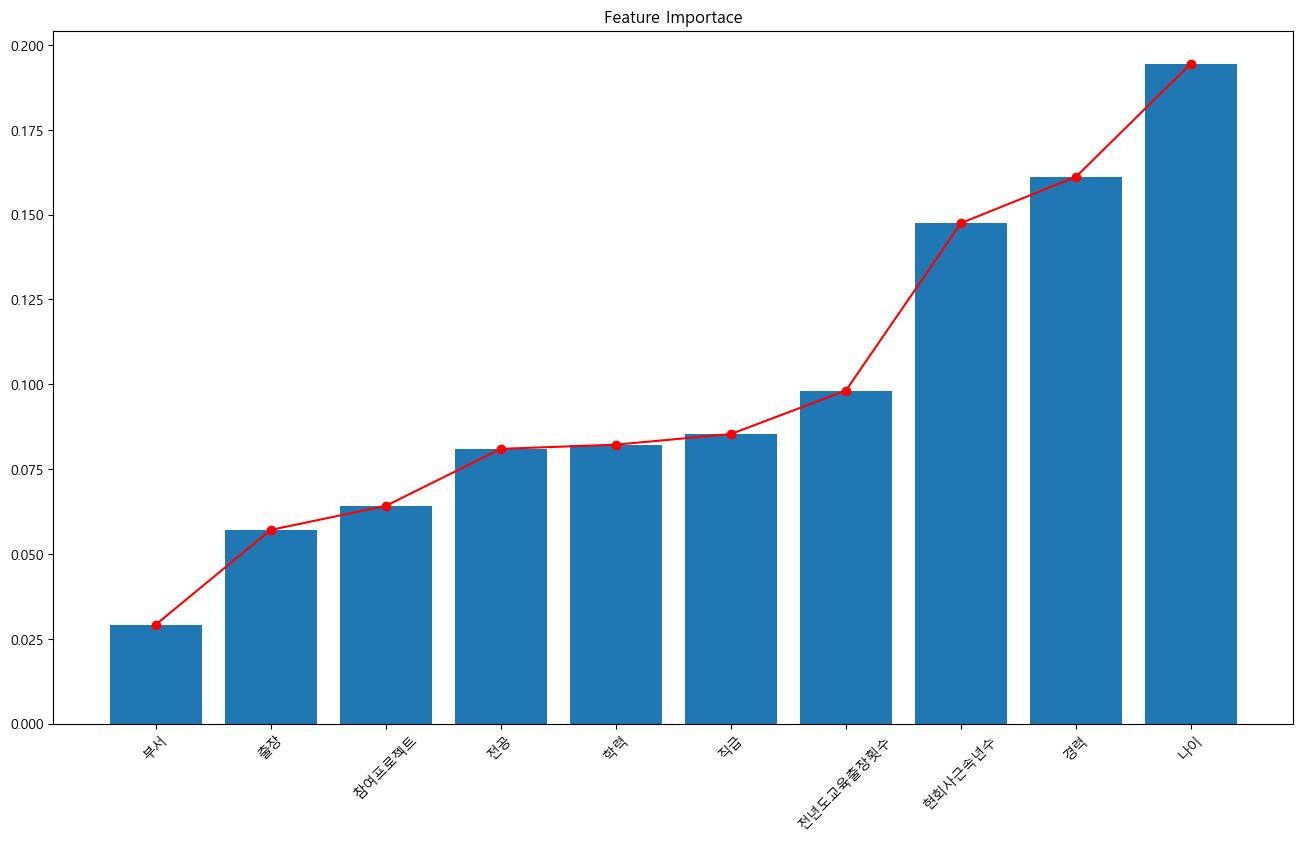

In [143]:
features.sort_values(by=['feature_importance'], ascending=True, inplace=True)
plt.figure(figsize=(16,9))
plt.plot(features.feature_name,features.feature_importance, color='red', marker='o')
plt.bar(features.feature_name,features.feature_importance)
plt.xticks(rotation=45)
plt.title("Feature Importace")
plt.show()

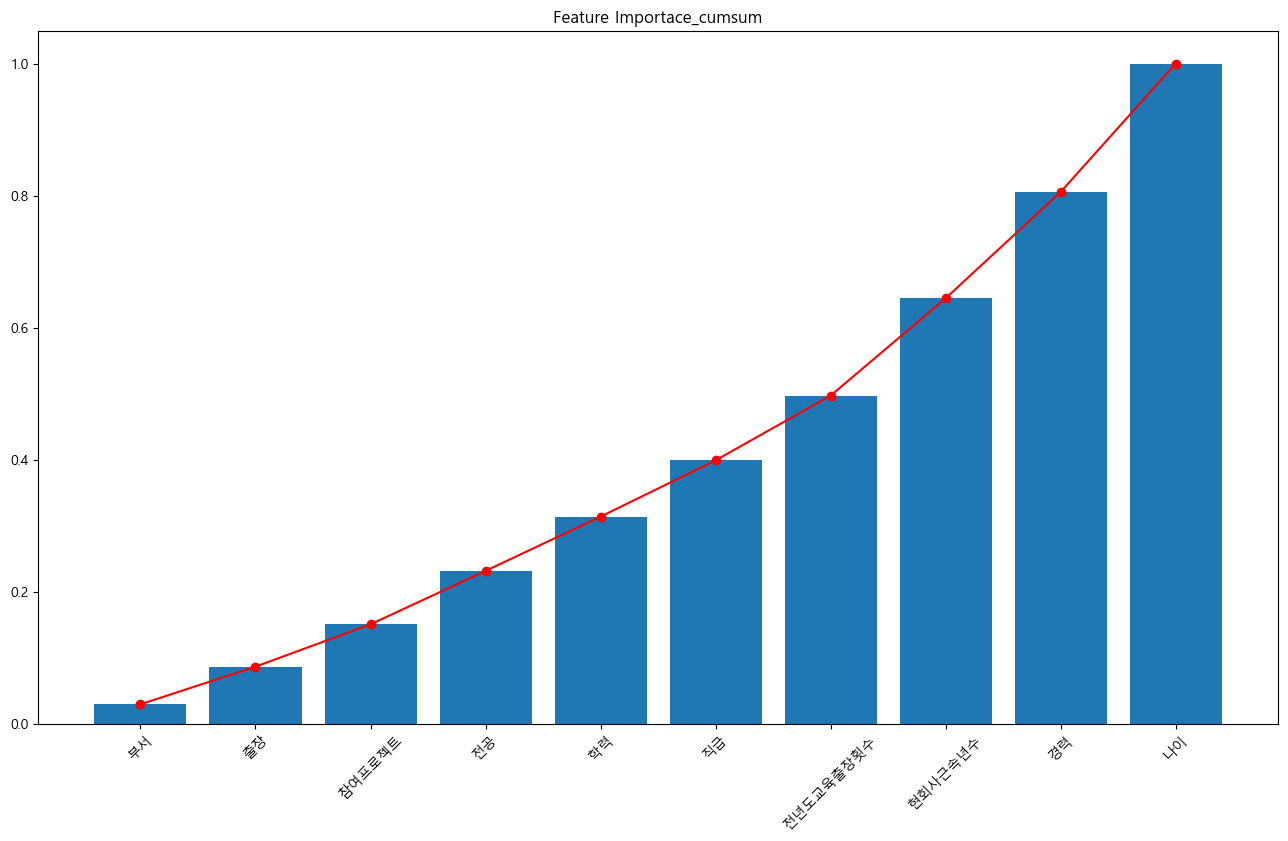

In [144]:
feature_y = np.cumsum(features.feature_importance)
# feature_y
features.sort_values(by=['feature_importance'], ascending=True, inplace=True)
plt.figure(figsize=(16,9))
plt.plot(features.feature_name,feature_y, color='red', marker='o')
plt.bar(features.feature_name,feature_y)
plt.xticks(rotation=45)
plt.title("Feature Importace_cumsum")
plt.show()

# feature_importance_ 확인 결과
1. cumsum 그래프가 꾸준히 상승하는 형태 : feature 종류의 부족일 수도
2. accuracy를 체크 후 모델 개선 방향 탐색

# 모델 결과

In [145]:
pred = rf_model.predict(np.array(X_test))
value = np.array(Y_test).ravel()

In [ ]:
pred.shape, value.shape

In [101]:
pd.crosstab(value,pred, rownames=['실제값'],colnames=['예측값'])

예측값,보통
실제값,
보통,124
좋다,23


# sample 모델 : RandomForeseClassifier : class_weight = balanced
- RandomForestClassifier로 우선 sampling 후 feature_importance_ 점검
- 이후 class_weight = "balanced" 점검
- 결과에 따라 타 모델 점검 및 smote 여부 점검

In [93]:
from sklearn.ensemble import RandomForestClassifier
import numpy as np

rf_cl_balanced_model = RandomForestClassifier(class_weight="balanced")
history = rf_cl_balanced_model.fit(np.array(X_train), np.array(Y_train).ravel())

In [94]:
history

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [95]:
pred = rf_cl_balanced_model.predict(np.array(X_test))
Y_test, pred

(     업무평가
 16     보통
 1057   보통
 908    보통
 1141   보통
 1244   보통
 ...   ...
 910    좋다
 1211   보통
 838    보통
 597    보통
 1108   보통
 
 [147 rows x 1 columns],
 array(['보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통', '보통',
        '보통', '보통', '보통', '

In [96]:
pd.crosstab(np.array(Y_test).ravel(),pred,rownames=['실제값'],colnames=['예측값'])

예측값,보통
실제값,
보통,124
좋다,23


In [97]:
Y_test[Y_test['업무평가']=='보통'].value_counts() # 좋다 예측값 0건

업무평가
보통      124
Name: count, dtype: int64

In [98]:
from sklearn.metrics import accuracy_score
acc = accuracy_score(Y_test, pred)

In [99]:
acc # 84.7% 정확도

0.8435374149659864

In [100]:
from sklearn.metrics import classification_report
report = classification_report(Y_test, pred)
print(report)

              precision    recall  f1-score   support

          보통       0.84      1.00      0.92       124
          좋다       0.00      0.00      0.00        23

    accuracy                           0.84       147
   macro avg       0.42      0.50      0.46       147
weighted avg       0.71      0.84      0.77       147



C:\Users\Admin\anaconda3\envs\llm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\envs\llm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\Admin\anaconda3\envs\llm\lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


# class_weight = "balanced" 이후에도 정확도는 84.7%
- 무엇보다 업무평가 4(뛰어남)에 대한 검증력이 약함
- 그런데 이게 잘 맞춰야하나에 대한 의문 : precision이 높아야하는 거 아닌가?